# 第7回 勉強会 (補足) — TF-IDF + ロジスティック回帰で解く & BERT と比較

ノート2では BERT（distilbert）でAmazonレビューの感情分析を解きました。
ここでは**補足問題**として、同じ不均衡データを **古典的な手法**
（**TF-IDF（n-gram）+ ロジスティック回帰**）で解き、ノート2の BERT と比較します。

ねらい:
- 「いきなり BERT」ではなく、**軽量・高速・解釈可能な強いベースライン**を持つ大切さ
- 不均衡対処（`class_weight="balanced"`）は古典手法でも同じ発想で効く
- **同じデータ分割・同じ評価指標**で BERT とフェアに比べる

ノート2と**まったく同じ train/valid 分割**（`load_amazon_binary` + 同じ seed・サイズ）を使います。

In [1]:
import json
import os

import japanize_matplotlib  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score,
)

from util import load_amazon_binary

%matplotlib inline
plt.rcParams["font.size"] = 12

LABELS = ["positive", "negative"]  # positive=0 / negative=1（少数派=negative）
MINORITY = 1

/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. データ準備（ノート2と同一の分割）

`load_amazon_binary()` はシャッフルに固定 seed を使うため、同じ引数なら毎回同じ並びです。
ノート2と同じ `EVAL_SIZE=400 / TRAIN_SIZE=800` で切り出せば、**同一の事例**になります。

In [2]:
texts, labels, _ = load_amazon_binary(max_lines=60000)

EVAL_SIZE, TRAIN_SIZE = 400, 800
valid_texts = texts[:EVAL_SIZE]
valid_labels = labels[:EVAL_SIZE]
train_texts = texts[EVAL_SIZE:EVAL_SIZE + TRAIN_SIZE]
train_labels = labels[EVAL_SIZE:EVAL_SIZE + TRAIN_SIZE]

train_counts = np.bincount(train_labels, minlength=2)
print(f"train: positive={train_counts[0]} / negative={train_counts[1]} "
      f"(positive率 {train_counts[0] / sum(train_counts):.1%})")
print(f"valid: {len(valid_texts)} 件")

train: positive=624 / negative=176 (positive率 78.0%)
valid: 400 件


## 1. TF-IDF 特徴量（語の n-gram, 1〜2グラム）

テキストを「単語・連接語（バイグラム）の重み付き出現」ベクトルに変換します。
- `ngram_range=(1, 2)`：単語 + 2語の並び（"not good" などを拾える）
- `min_df=2`：2文書未満にしか出ない語は捨てる（ノイズ・過学習対策）
- `sublinear_tf=True`：出現回数を log スケールに

In [3]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, sublinear_tf=True, max_features=20000
)
X_train = vectorizer.fit_transform(train_texts)
X_valid = vectorizer.transform(valid_texts)
print("特徴量ベクトルの形 (事例数, 語彙数):", X_train.shape)

特徴量ベクトルの形 (事例数, 語彙数): (800, 4120)


### どんな BOW（語彙）が作られたか

`TfidfVectorizer` は訓練データから **語彙（vocabulary）** を作ります。
`ngram_range=(1, 2)` なので、単語（**ユニグラム**）に加えて
「2語の並び」（**バイグラム**, 例: `not good`）も特徴に入ります。

In [4]:
feature_names = vectorizer.get_feature_names_out()
unigrams = [f for f in feature_names if " " not in f]
bigrams = [f for f in feature_names if " " in f]
print(f"語彙数（特徴の総数）: {len(feature_names)}")
print(f"  ユニグラム: {len(unigrams)} / バイグラム: {len(bigrams)}")
print("ユニグラム例:", unigrams[:12])
print("バイグラム例:", bigrams[:12])

語彙数（特徴の総数）: 4120
  ユニグラム: 1534 / バイグラム: 2586
ユニグラム例: ['00', '10', '1000', '12', '15', '1b', '20', '22', '24', '26', '30', '34']
バイグラム例: ['10 years', '20 minutes', '30 minutes', '34 it', 'able to', 'about 30', 'about half', 'about hours', 'about it', 'about that', 'about the', 'about this']


### 1文が実際にどんなベクトルになるか

1件のレビューについて、**ゼロでない特徴（＝出現した n-gram）とその TF-IDF 重み**を見ます。
ベクトルは「語彙数」ぶんの次元を持ちますが、実際に値が入るのはごく一部＝**疎ベクトル**です。

In [5]:
doc_idx = 0
print("レビュー:", train_texts[doc_idx][:200])
row = X_train[doc_idx].tocoo()
fired = sorted(zip(row.col, row.data), key=lambda cw: -cw[1])
print(f"\nゼロでない特徴: {len(fired)} 個（語彙 {len(feature_names)} 次元のうち）")
print("重みの大きい順:")
for col, w in fired[:15]:
    print(f"  {feature_names[col]:<22} tf-idf={w:.3f}")

レビュー: I have used a few products by Follain to this date so I was curious to see how this mattifying moisturizer would perform. It comes in a little pump dispenser. It is on the more inexpensive side of the

ゼロでない特徴: 94 個（語彙 4120 次元のうち）
重みの大きい順:
  the moisturizer        tf-idf=0.209
  moisturizer            tf-idf=0.205
  line                   tf-idf=0.178
  fragrance              tf-idf=0.178
  perform                tf-idf=0.124
  spectrum               tf-idf=0.124
  itself                 tf-idf=0.124
  absorbs                tf-idf=0.124
  behind                 tf-idf=0.124
  pretty much            tf-idf=0.124
  of fragrance           tf-idf=0.124
  is pleasant            tf-idf=0.124
  lightweight it         tf-idf=0.124
  very quickly           tf-idf=0.124
  quickly into           tf-idf=0.124


In [6]:
density = X_train.nnz / (X_train.shape[0] * X_train.shape[1])
print(f"特徴量行列: {X_train.shape}（事例数 × 語彙数）")
print(f"密度（非ゼロの割合）: {density:.4%}")
print(f"1文あたり平均の非ゼロ特徴数: {X_train.nnz / X_train.shape[0]:.1f}")

特徴量行列: (800, 4120)（事例数 × 語彙数）
密度（非ゼロの割合）: 0.8680%
1文あたり平均の非ゼロ特徴数: 35.8


### BOW + TF-IDF と BERT の対比（同じ文を別の方法で数値化している）

| | BOW + TF-IDF（このノート） | BERT のトークナイズ（ノート2） |
|---|---|---|
| 単位 | 単語・バイグラム | サブワード（WordPiece） |
| 語彙外の語 | **無視（捨てる）** | サブワードに分割して表現 |
| 語順 | ほぼ無視（bigram で一部だけ補う） | 位置・文脈を考慮 |
| ベクトル | 高次元・**疎**・固定語彙 | 低次元・**密**・文脈依存 |
| 解釈 | 係数で直接読める（セクション5） | 直接は読みにくい |

## 2. 評価関数（ノート2と同じ指標）

不均衡なので accuracy だけでなく **macro-F1 / balanced accuracy /
少数クラス（negative）の recall / 混同行列**を見ます。

In [7]:
def report_metrics(y_true, y_pred, title):
    acc = np.mean(np.array(y_true) == np.array(y_pred))
    m = {
        "accuracy": acc,
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "minority_recall": recall_score(y_true, y_pred, pos_label=MINORITY,
                                        zero_division=0),
    }
    print(f"▼ {title}")
    print(f"  accuracy        : {m['accuracy']:.3f}")
    print(f"  macro-F1        : {m['macro_f1']:.3f}")
    print(f"  balanced acc    : {m['balanced_acc']:.3f}")
    print(f"  negative recall : {m['minority_recall']:.3f}  ← 少数クラスを拾えているか")
    print(classification_report(y_true, y_pred, target_names=LABELS,
                                zero_division=0, digits=3))
    return m


def show_confusion(y_true, y_pred, title):
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred, labels=[0, 1]), display_labels=LABELS
    ).plot()
    plt.title(title)
    plt.show()

## 3. ロジスティック回帰（対処なし）

まずは不均衡を気にせず素直に学習。

▼ LogReg（対処なし）
  accuracy        : 0.850
  macro-F1        : 0.601
  balanced acc    : 0.583
  negative recall : 0.167  ← 少数クラスを拾えているか
              precision    recall  f1-score   support

    positive      0.845     1.000     0.916       328
    negative      1.000     0.167     0.286        72

    accuracy                          0.850       400
   macro avg      0.923     0.583     0.601       400
weighted avg      0.873     0.850     0.803       400



/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


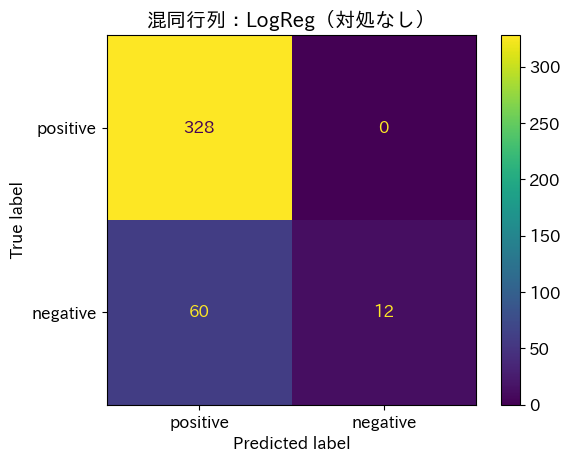

In [8]:
clf_plain = LogisticRegression(max_iter=1000)
clf_plain.fit(X_train, train_labels)
y_plain = clf_plain.predict(X_valid)
m_lr_plain = report_metrics(valid_labels, y_plain, "LogReg（対処なし）")
show_confusion(valid_labels, y_plain, "混同行列：LogReg（対処なし）")

## 4. ロジスティック回帰（`class_weight="balanced"`）＝ 不均衡対処

BERT のクラス重みと同じ発想で、少数クラスの誤りを重く扱います（逆頻度で自動設定）。

▼ LogReg（balanced）
  accuracy        : 0.865
  macro-F1        : 0.774
  balanced acc    : 0.777
  negative recall : 0.639  ← 少数クラスを拾えているか
              precision    recall  f1-score   support

    positive      0.920     0.915     0.917       328
    negative      0.622     0.639     0.630        72

    accuracy                          0.865       400
   macro avg      0.771     0.777     0.774       400
weighted avg      0.866     0.865     0.866       400



/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/yasuthompson/Documents/llm-book/dai-7-kai/.venv/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


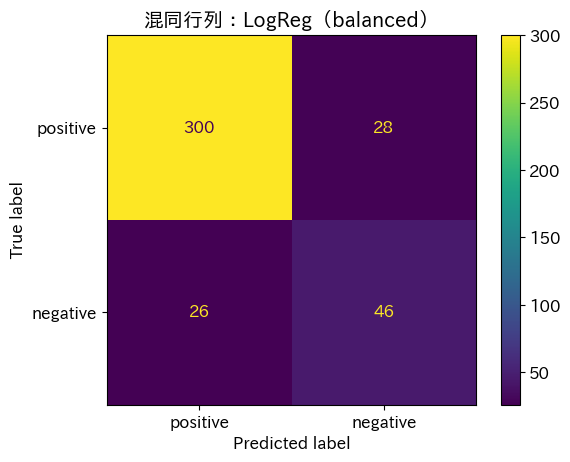

In [9]:
clf_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
clf_bal.fit(X_train, train_labels)
y_bal = clf_bal.predict(X_valid)
m_lr_bal = report_metrics(valid_labels, y_bal, "LogReg（balanced）")
show_confusion(valid_labels, y_bal, "混同行列：LogReg（balanced）")

## 5. 解釈性ボーナス — どの語が効いているか

線形モデルなので、各語（特徴）の**係数**がそのまま「効き目」になります。
二値ロジスティック回帰の係数はクラス1（= negative）方向への寄与なので、
係数が大きい語ほど negative 寄り、小さい（負に大きい）語ほど positive 寄りです。

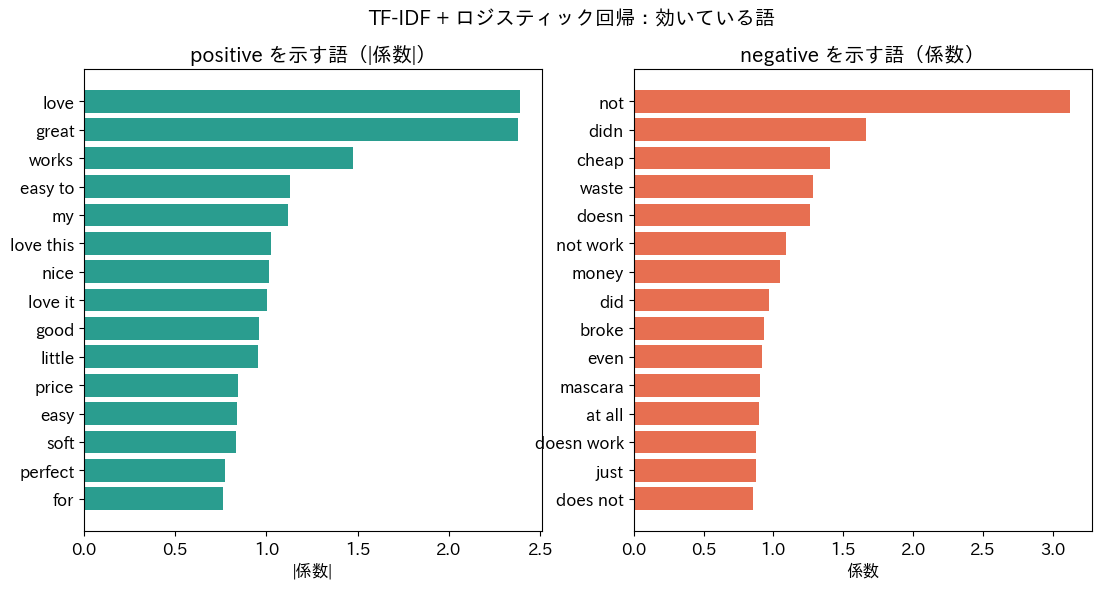

In [10]:
feature_names = np.array(vectorizer.get_feature_names_out())
coef = clf_bal.coef_[0]
top_neg = np.argsort(coef)[-15:]       # 係数が大きい = negative 寄り
top_pos = np.argsort(coef)[:15]        # 係数が小さい = positive 寄り

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].barh(feature_names[top_pos][::-1], -coef[top_pos][::-1], color="#2a9d8f")
axes[0].set_title("positive を示す語（|係数|）")
axes[0].set_xlabel("|係数|")
axes[1].barh(feature_names[top_neg], coef[top_neg], color="#e76f51")
axes[1].set_title("negative を示す語（係数）")
axes[1].set_xlabel("係数")
fig.suptitle("TF-IDF + ロジスティック回帰：効いている語")
plt.show()

「素性 → 予測」が人間に読めるのが線形モデルの強み。
BERT は精度で勝つことが多い一方、こうした**直接的な解釈**は得にくいです。

## 6. BERT（ノート2）との比較

ノート2が保存した結果（`output/nb2_bert_results.json`）を読み込み、
ロジスティック回帰と**同じ指標・同じ検証セット**で並べます。
（ファイルが無い場合は、ノート2実行時に観測した値をフォールバックとして使います）

In [11]:
fallback_bert = {
    "対処なし": {"accuracy": 0.820, "macro_f1": 0.451,
                 "balanced_acc": 0.500, "minority_recall": 0.000},
    "クラス重み": {"accuracy": 0.833, "macro_f1": 0.774,
                   "balanced_acc": 0.860, "minority_recall": 0.903},
}
path = "output/nb2_bert_results.json"
if os.path.exists(path):
    with open(path, encoding="utf-8") as f:
        bert = json.load(f)
    print("ノート2の結果を読み込みました:", path)
else:
    bert = fallback_bert
    print("⚠ JSON が無いのでフォールバック値を使用（先に 02 を実行すると正確になります）")

comparison = {
    "LogReg": m_lr_plain,
    "LogReg(balanced)": m_lr_bal,
    "BERT(対処なし)": bert["対処なし"],
    "BERT(クラス重み)": bert["クラス重み"],
}

metric_keys = ["accuracy", "macro_f1", "balanced_acc", "minority_recall"]
metric_labels = ["accuracy", "macro-F1", "balanced acc", "negative recall"]

print(f"\n{'手法':<18}" + "".join(f"{lb:>16}" for lb in metric_labels))
for name, m in comparison.items():
    print(f"{name:<18}" + "".join(f"{m[k]:>16.3f}" for k in metric_keys))

ノート2の結果を読み込みました: output/nb2_bert_results.json

手法                        accuracy        macro-F1    balanced acc negative recall
LogReg                       0.850           0.601           0.583           0.167
LogReg(balanced)             0.865           0.774           0.777           0.639
BERT(対処なし)                   0.820           0.451           0.500           0.000
BERT(クラス重み)                  0.833           0.774           0.860           0.903


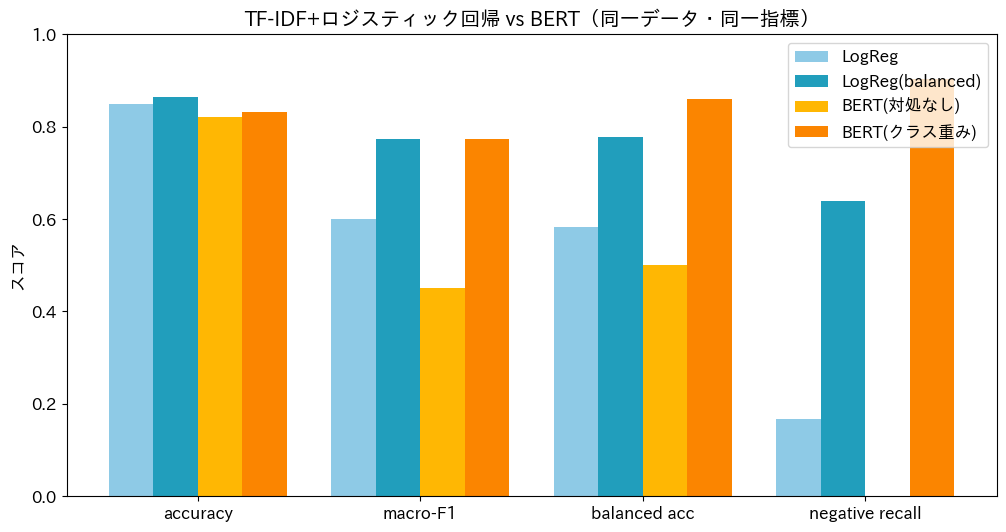

In [12]:
x = np.arange(len(metric_keys))
methods = list(comparison.keys())
width = 0.8 / len(methods)
colors = ["#8ecae6", "#219ebc", "#ffb703", "#fb8500"]

plt.figure(figsize=(12, 6))
for i, name in enumerate(methods):
    vals = [comparison[name][k] for k in metric_keys]
    plt.bar(x + (i - (len(methods) - 1) / 2) * width, vals, width,
            label=name, color=colors[i])
plt.xticks(x, metric_labels)
plt.ylim(0, 1)
plt.ylabel("スコア")
plt.title("TF-IDF+ロジスティック回帰 vs BERT（同一データ・同一指標）")
plt.legend()
plt.show()

## 7. エラー分析の比較 — BERT と ロジスティック回帰はどこで間違う？

ノート2の **BERT(クラス重み)** と、ここの **LogReg(balanced)** の予測を、
検証セット上で**1件ずつ突き合わせ**ます。誤りが「共通」なのか「相補的」なのかが、
このあとの融合（RRF）が効くかどうかを左右します。
（両ノートとも同じ `load_amazon_binary` + 同じ分割なので、検証セットの並びは一致）

In [13]:
data = np.load("output/nb2_bert_preds.npz")
y_true_arr = np.array(valid_labels)
assert np.array_equal(y_true_arr, data["y_true"]), "検証セットの並びが一致していません"

bert_pred = data["pred_weighted"]
bert_prob_neg = data["prob_weighted"][:, 1]   # P(negative)
lr_pred = y_bal                                # セクション4の LogReg(balanced)
lr_prob_neg = clf_bal.predict_proba(X_valid)[:, 1]

bert_correct = bert_pred == y_true_arr
lr_correct = lr_pred == y_true_arr
both_correct = int(np.sum(bert_correct & lr_correct))
both_wrong = int(np.sum(~bert_correct & ~lr_correct))
bert_only_wrong = int(np.sum(~bert_correct & lr_correct))
lr_only_wrong = int(np.sum(bert_correct & ~lr_correct))

print(f"予測の一致率（同じラベルを出した割合）: {np.mean(bert_pred == lr_pred):.1%}")
print(f"両方正解         : {both_correct}")
print(f"両方誤り（共通の弱点）: {both_wrong}")
print(f"BERTのみ誤り      : {bert_only_wrong}")
print(f"LogRegのみ誤り    : {lr_only_wrong}")

予測の一致率（同じラベルを出した割合）: 78.2%
両方正解         : 296
両方誤り（共通の弱点）: 17
BERTのみ誤り      : 50
LogRegのみ誤り    : 37


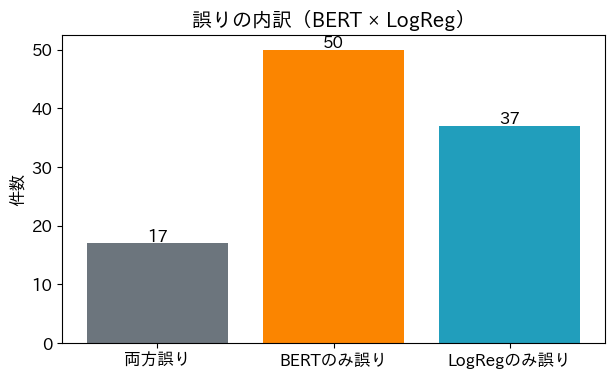

In [14]:
plt.figure(figsize=(7, 4))
labels_ = ["両方誤り", "BERTのみ誤り", "LogRegのみ誤り"]
vals_ = [both_wrong, bert_only_wrong, lr_only_wrong]
plt.bar(labels_, vals_, color=["#6c757d", "#fb8500", "#219ebc"])
for i, v in enumerate(vals_):
    plt.text(i, v + 0.3, str(v), ha="center")
plt.ylabel("件数")
plt.title("誤りの内訳（BERT × LogReg）")
plt.show()

**共通して誤る事例**（両方が外す＝本質的に難しい事例）を見てみます。

In [15]:
both_wrong_idx = np.where(~bert_correct & ~lr_correct)[0]
for i in both_wrong_idx[:4]:
    print(f"正解={LABELS[y_true_arr[i]]} / BERT={LABELS[bert_pred[i]]} / "
          f"LogReg={LABELS[lr_pred[i]]}")
    print("  ", valid_texts[i][:180])
    print("-" * 60)

正解=negative / BERT=positive / LogReg=positive
   These are the worst makeup sponges I've ever used. The quality is horrible. They are flimsy and have no substance to them. They disintegrate while you're using them. I've gotten mu
------------------------------------------------------------
正解=positive / BERT=negative / LogReg=negative
   Just got them, so hopefully it will serve it's purpose.
------------------------------------------------------------
正解=positive / BERT=negative / LogReg=negative
   I didn't find any difference between 1875watts to 2200watts, look is different but power is same. I was expecting more powerful but it's not. Or I got the lemon, don't know... Less
------------------------------------------------------------
正解=negative / BERT=positive / LogReg=positive
   These are only good for one hand.  Hardly any roughness on them.  I will stick to the local salon to buy these types of things.
------------------------------------------------------------


**片方だけ誤る事例**（＝もう片方が救える＝相補的）。融合が効く余地はここにあります。

In [16]:
print("◆ BERT は正解・LogReg が誤り:")
for i in np.where(bert_correct & ~lr_correct)[0][:2]:
    print(f"  正解={LABELS[y_true_arr[i]]} / LogReg={LABELS[lr_pred[i]]} : "
          f"{valid_texts[i][:140]}")
print("\n◆ LogReg は正解・BERT が誤り:")
for i in np.where(lr_correct & ~bert_correct)[0][:2]:
    print(f"  正解={LABELS[y_true_arr[i]]} / BERT={LABELS[bert_pred[i]]} : "
          f"{valid_texts[i][:140]}")

◆ BERT は正解・LogReg が誤り:
  正解=positive / LogReg=negative : Look like picture
  正解=negative / LogReg=positive : These are tiny and have zero elastic properties.

◆ LogReg は正解・BERT が誤り:
  正解=positive / BERT=negative : Daughter like it
  正解=positive / BERT=negative : nice product. absorbs into the skin well. not sticky


誤りが完全に一致せず**相補的な部分がある**なら、2モデルを融合すると改善が期待できます。
次にそれを **RRF** で確かめます。

## 8. RRF（Reciprocal Rank Fusion）で2モデルを融合

RRF はもともと**検索結果の順位融合**の手法です。各モデルが付けた
「**どれだけ negative らしいか**」の順位を融合します：

$$\text{score}_{\text{RRF}}(x) = \sum_{\text{model}} \frac{1}{k + \text{rank}_{\text{model}}(x)}, \quad k=60$$

RRF は**順位ベース**なので、2段階で見ます：
1. **ランキング性能**（negative をどれだけ上位に集められるか）を AUC で評価 ← RRFの本領
2. **分類**するには動作点が必要 → ここでは「**訓練データと同じ negative 比率**」だけ
   negative と予測する、という操作点を採用

In [17]:
def to_ranks(scores):
    """スコア降順の順位（1始まり）を返す"""
    order = np.argsort(-np.asarray(scores))
    ranks = np.empty(len(scores), dtype=int)
    ranks[order] = np.arange(1, len(scores) + 1)
    return ranks


def rrf_fuse(score_list, k=60):
    fused = np.zeros(len(score_list[0]))
    for s in score_list:
        fused += 1.0 / (k + to_ranks(s))
    return fused


rrf_neg = rrf_fuse([bert_prob_neg, lr_prob_neg], k=60)
avg_neg = (bert_prob_neg + lr_prob_neg) / 2  # 参考: 単純な確率平均

# --- (1) ランキング性能（negative=1 をどれだけ上位に集められるか）---
y_is_neg = (y_true_arr == 1).astype(int)
print("『negative を上位に集める』ランキング性能（高いほど良い）:")
print(f"{'手法':<16}{'ROC-AUC':>10}{'PR-AUC':>10}")
for name, s in [("BERT(重み)", bert_prob_neg), ("LogReg(bal)", lr_prob_neg),
                ("確率平均(参考)", avg_neg), ("RRF融合", rrf_neg)]:
    print(f"{name:<16}{roc_auc_score(y_is_neg, s):>10.3f}"
          f"{average_precision_score(y_is_neg, s):>10.3f}")

『negative を上位に集める』ランキング性能（高いほど良い）:
手法                 ROC-AUC    PR-AUC


BERT(重み)             0.920     0.724
LogReg(bal)          0.888     0.714
確率平均(参考)             0.929     0.774
RRF融合                0.935     0.785


### RRF を分類に落とす（動作点 = 訓練の negative 比率）

訓練の negative 比率 = 22.0% → 検証 400 件中 上位 88 件を negative と予測
▼ RRF融合（順位融合 → 上位を negative）
  accuracy        : 0.890
  macro-F1        : 0.828
  balanced acc    : 0.857
  negative recall : 0.806  ← 少数クラスを拾えているか
              precision    recall  f1-score   support

    positive      0.955     0.909     0.931       328
    negative      0.659     0.806     0.725        72

    accuracy                          0.890       400
   macro avg      0.807     0.857     0.828       400
weighted avg      0.902     0.890     0.894       400



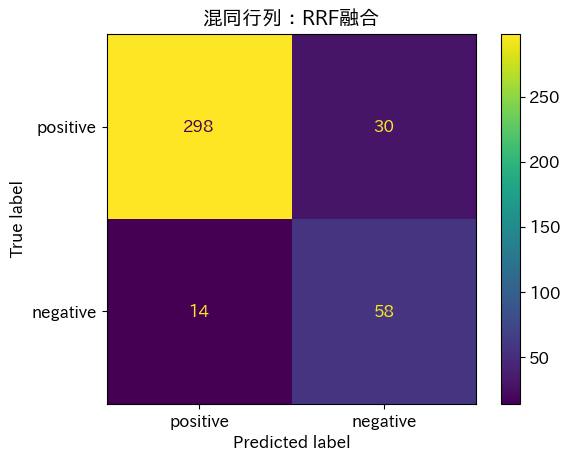

In [18]:
pi = train_counts[1] / train_counts.sum()
n_neg_pred = int(round(pi * len(y_true_arr)))
print(f"訓練の negative 比率 = {pi:.1%} → 検証 {len(y_true_arr)} 件中 "
      f"上位 {n_neg_pred} 件を negative と予測")


def topk_to_labels(score, k_neg):
    order = np.argsort(-score)
    pred = np.zeros(len(score), dtype=int)
    pred[order[:k_neg]] = 1
    return pred


y_rrf = topk_to_labels(rrf_neg, n_neg_pred)
m_rrf = report_metrics(y_true_arr, y_rrf, "RRF融合（順位融合 → 上位を negative）")
show_confusion(y_true_arr, y_rrf, "混同行列：RRF融合")

### 最終比較：単体モデル vs RRF融合

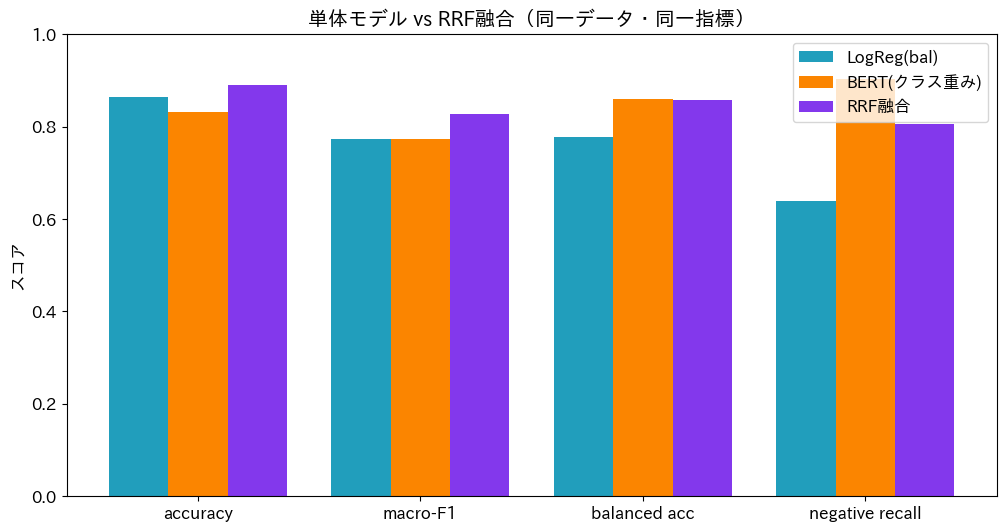


手法                      accuracy        macro-F1    balanced acc negative recall
LogReg(bal)                0.865           0.774           0.777           0.639
BERT(クラス重み)                0.833           0.774           0.860           0.903
RRF融合                      0.890           0.828           0.857           0.806


In [19]:
final = {
    "LogReg(bal)": m_lr_bal,
    "BERT(クラス重み)": comparison["BERT(クラス重み)"],
    "RRF融合": m_rrf,
}
x = np.arange(len(metric_keys))
names = list(final.keys())
width = 0.8 / len(names)
colors = ["#219ebc", "#fb8500", "#8338ec"]

plt.figure(figsize=(12, 6))
for i, name in enumerate(names):
    vals = [final[name][k] for k in metric_keys]
    plt.bar(x + (i - (len(names) - 1) / 2) * width, vals, width,
            label=name, color=colors[i])
plt.xticks(x, metric_labels)
plt.ylim(0, 1)
plt.ylabel("スコア")
plt.title("単体モデル vs RRF融合（同一データ・同一指標）")
plt.legend()
plt.show()

print(f"\n{'手法':<16}" + "".join(f"{lb:>16}" for lb in metric_labels))
for name, m in final.items():
    print(f"{name:<16}" + "".join(f"{m[k]:>16.3f}" for k in metric_keys))

> **⚠ 比較条件についての注意**
> この勉強会の設定は **CPUで完走させるための小規模設定**（train 800 件 × 1 エポック）です。
> この regime では **BERT はやや過小学習**になりやすく、古典手法が実際よりも有利に見えます。
> 学習データを増やす／エポックを増やす／GPUで本気で回すと、BERT 側が
> （特に文脈や言い回しが効く難しめの事例で）差を広げるのが一般的です。
> **「古典 > BERT」と一般化しないこと**。あくまで「強い古典ベースラインの価値」を見るのが目的です。

## まとめ・考察

- **TF-IDF + ロジスティック回帰は非常に強いベースライン**。短めのレビュー文で
  「良い/悪い」が明確な語に出る感情分析では、BERT に肉薄（または匹敵）することが多い。
  （実際この小規模設定では accuracy / macro-F1 で BERT と互角〜上回った）
- **不均衡対処は古典手法でも同じ**：`class_weight="balanced"` で
  少数クラス（negative）の recall が改善し、balanced accuracy が上がる。
- 古典手法の利点：**軽量・高速・省メモリ・解釈可能**（効いている語が読める）。
- BERT が効きやすいのは：**文脈・否定・言い回しの機微**が効くタスク、
  学習データが少なく**事前学習の転移**が活きる場面、ドメインが難しい場合など。

**エラー分析の比較（セクション7）から:**
- 2モデルの誤りは**完全には一致せず、相補的な部分がある**（片方だけが救える事例がある）
- **両方が外す事例**は本質的に難しい（皮肉・短すぎ・文脈依存など）

**RRF 融合（セクション8）から:**
- RRF は順位ベースの融合。**ランキング性能（negative を上位に集める力）**で見ると、
  融合は単体より**安定**しやすい（PR-AUC / ROC-AUC）
- ただし分類に使うには**動作点（しきい値）が必要**で、そこは別途決める必要がある
- 相補性が小さい／一方が明確に強いときは、融合の上積みは限定的になることもある

→ 「まず強い古典ベースラインを作り、BERT がそれを**どれだけ上回るか**で
  追加コストの妥当性を判断する」「誤りが相補的なら**融合**も検討する」のが実務的な進め方です。